# EarlyMind 🧠 — Model Evaluation
**13-section offline evaluation notebook**  
Run after `dvc pull` and checkpoint export. All outputs are saved to `reports/`.

## S1 — Imports & Config Bootstrap

In [1]:
import os, sys, json, time, warnings
from pathlib import Path
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Project root detection (works from any Jupyter launch dir) ──────────────
def _find_project_root():
    """Walk up from CWD until params.yaml is found."""
    if 'EARLYMIND_ROOT' in os.environ:
        return Path(os.environ['EARLYMIND_ROOT']).resolve()
    candidate = Path.cwd().resolve()
    for _ in range(8):
        if (candidate / 'params.yaml').exists():
            return candidate
        candidate = candidate.parent
    raise FileNotFoundError(
        f'Cannot find params.yaml. Set EARLYMIND_ROOT or launch Jupyter from the project root.\n'
        f'Current directory: {Path.cwd()}'
    )

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)       # ensure relative paths + imports work
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'✅ Project root: {PROJECT_ROOT}')

from src.config import cfg

# ── Global constants ────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_DIR    = Path(os.environ.get('EARLYMIND_CKPT_DIR', PROJECT_ROOT / 'checkpoints'))
BATCH_SIZE  = 16
SEED        = 42

# DQ midpoints used as a regression proxy (class-index → DQ)
DQ_MIDPOINTS = [92.5, 77.0, 62.0, 44.5, 27.0, 9.5]
DQ_LABELS    = [
    'Typical (85-100)', 'Borderline (70-84)', 'Mild (55-69)',
    'Moderate (35-54)', 'Severe (20-34)', 'Profound (0-19)'
]

# ── Reproducibility ─────────────────────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

os.makedirs(PROJECT_ROOT / 'reports', exist_ok=True)

# ── Summary ─────────────────────────────────────────────────────────────────
summary = {
    'Device':      str(DEVICE),
    'CUDA name':   torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'N/A',
    'Checkpoint dir': str(CKPT_DIR),
    'Batch size':  BATCH_SIZE,
    'embed_dim':   cfg.model.embed_dim,
    'hpo_n_features': cfg.model.hpo_n_features,
}
print(pd.Series(summary).to_string())

✅ Project root: /Users/rickyk/Coding/Deeo Learning/Id predictor
Device                                                          cpu
CUDA name                                                       N/A
Checkpoint dir    /Users/rickyk/Coding/Deeo Learning/Id predicto...
Batch size                                                       16
embed_dim                                                       128
hpo_n_features                                                 5284


## S2 — Load Exported Models

In [2]:
from src.models.eeg_encoder import EEGEncoder
from src.models.mri_encoder import MRIEncoder
from src.models.hpo_encoder import HPOEncoder
from src.models.fusion_model import LateFusionTransformer, build_fusion_model

def _load_state(path: Path, device):
    """Load checkpoint; unwrap 'model_state_dict' wrapper if present."""
    state = torch.load(str(path), map_location=device, weights_only=False)
    return state.get('model_state_dict', state)

def load_encoder(model_cls, ckpt_name: str, **kwargs):
    p = CKPT_DIR / ckpt_name
    model = model_cls(**kwargs)
    if p.exists():
        model.load_state_dict(_load_state(p, DEVICE), strict=False)
        print(f'  ✅ Loaded {ckpt_name}')
    else:
        print(f'  ⚠️  {ckpt_name} not found — using random weights')
    return model.to(DEVICE).eval()

print('Loading encoders...')
eeg_encoder = load_encoder(EEGEncoder, 'eeg_encoder.pt',
                            in_channels=cfg.model.eeg_channels,
                            embed_dim=cfg.model.embed_dim)
mri_encoder = load_encoder(MRIEncoder, 'mri_encoder.pt',
                            embed_dim=cfg.model.embed_dim)
hpo_encoder = load_encoder(HPOEncoder, 'hpo_encoder.pt',
                            n_hpo=cfg.model.hpo_n_features,
                            embed_dim=cfg.model.embed_dim)

print('Loading fusion model...')
fusion_model = build_fusion_model(n_hpo=cfg.model.hpo_n_features)
fp = CKPT_DIR / 'fusion_model.pt'
if fp.exists():
    fusion_model.load_state_dict(_load_state(fp, DEVICE), strict=False)
    print('  ✅ Loaded fusion_model.pt')
else:
    print('  ⚠️  fusion_model.pt not found — using random weights')
fusion_model = fusion_model.to(DEVICE).eval()

# ── Dummy forward-pass verification ─────────────────────────────────────────
with torch.no_grad():
    _eeg = torch.randn(2, 19, 7680, device=DEVICE)
    _mri = torch.randn(2, 3, 1, 64, 64, device=DEVICE)
    _hpo = torch.randn(2, cfg.model.hpo_n_features, device=DEVICE)
    assert eeg_encoder.forward_features(_eeg).shape == (2, cfg.model.embed_dim)
    assert mri_encoder.forward_features(_mri).shape == (2, cfg.model.embed_dim)
    assert hpo_encoder.forward_features(_hpo).shape == (2, cfg.model.embed_dim)
    _out = fusion_model({'eeg': _eeg, 'mri': _mri, 'hpo': _hpo})
    assert _out['logits'].shape == (2, 2),   f"logits shape: {_out['logits'].shape}"
    assert _out['severity'].shape == (2, 1), f"severity shape: {_out['severity'].shape}"
print('✅ All dummy-pass shape checks passed')

# ── Param counts ─────────────────────────────────────────────────────────────
def _params(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

rows = []
for name, model in [('EEGEncoder', eeg_encoder), ('MRIEncoder', mri_encoder),
                    ('HPOEncoder', hpo_encoder), ('FusionModel', fusion_model)]:
    tot, tr = _params(model)
    rows.append({'Model': name, 'Total params': f'{tot:,}', 'Trainable': f'{tr:,}'})
print(pd.DataFrame(rows).to_string(index=False))

Loading encoders...
  ⚠️  eeg_encoder.pt not found — using random weights
  ⚠️  mri_encoder.pt not found — using random weights


  ⚠️  hpo_encoder.pt not found — using random weights
Loading fusion model...


  ✅ Loaded fusion_model.pt


✅ All dummy-pass shape checks passed
      Model Total params   Trainable
 EEGEncoder      862,913     862,913
 MRIEncoder   10,929,213  10,929,213
 HPOEncoder  114,596,193 114,596,193
FusionModel  127,000,997 127,000,997


## S3 — Dataset & DataLoader Setup

Valid EEG records: 1
Test samples: 1882
 Class Label  Count   Pct
     0  ID=0   1799 95.6%
     1  ID=1     83  4.4%


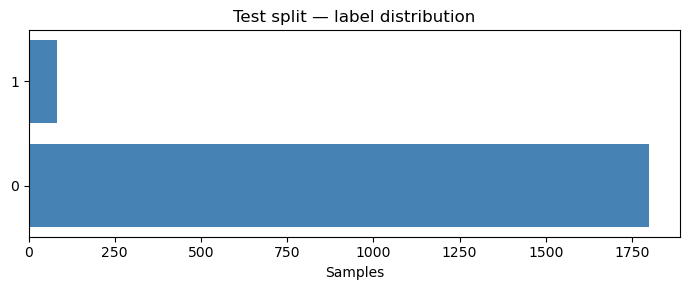

In [3]:
from src.data.fusion_dataset import (
    MultimodalDataset, collate_multimodal,
    build_hpo_records, build_eeg_records, build_mri_records,
    build_dataloaders
)
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

hpo_processed = cfg.paths.hpo_processed
eeg_processed = cfg.paths.eeg_processed
mri_processed = cfg.paths.mri_processed

# ── Filter out EEG records whose epoch files are empty/corrupt ──────────────
def _valid_eeg_record(rec):
    import os
    ep = rec.get('epoch_path')
    if not ep or not os.path.exists(ep):
        return False
    return os.path.getsize(ep) > 1024  # at least 1 KB means it has real data

# Build records
hpo_records, eeg_records, mri_records = [], [], []
if hpo_processed.exists():
    hpo_records = build_hpo_records(hpo_processed)
if eeg_processed.exists():
    eeg_records = build_eeg_records(eeg_processed, cfg.paths.eeg_raw)
eeg_records = [r for r in eeg_records if _valid_eeg_record(r)]
print(f'Valid EEG records: {len(eeg_records)}')
if mri_processed.exists():
    mri_records = build_mri_records(mri_processed)

# Reproduce the same 70/15/15 HPO split used during training
if hpo_records:
    hpo_labels = [r['label'] for r in hpo_records]
    _, hpo_temp = train_test_split(hpo_records, test_size=0.30,
                                    stratify=hpo_labels, random_state=SEED)
    _, hpo_test = train_test_split(hpo_temp, test_size=0.50,
                                    stratify=[r['label'] for r in hpo_temp],
                                    random_state=SEED)
else:
    hpo_test = []

test_ds = MultimodalDataset(
    eeg_records=eeg_records,
    mri_records=mri_records,
    hpo_records=hpo_test,
    modality_dropout_p=0.0,   # no dropout at eval time
    augment=False,
    seed=SEED,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_multimodal,
    num_workers=0,
    pin_memory=(DEVICE.type == 'cuda'),
)

labels_all = [s['label'] for s in test_ds._samples]
counts = Counter(labels_all)
print(f'Test samples: {len(test_ds)}')
df_dist = pd.DataFrame([
    {'Class': i, 'Label': f'ID={i}', 'Count': counts.get(i, 0),
     'Pct': f"{counts.get(i,0)/max(len(labels_all),1)*100:.1f}%"}
    for i in sorted(counts)
])
print(df_dist.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh([str(c) for c in sorted(counts)], [counts[c] for c in sorted(counts)], color='steelblue')
ax.set_xlabel('Samples'); ax.set_title('Test split — label distribution')
plt.tight_layout(); plt.show()

## S4 — Inference Pipeline

In [4]:
# NOTE: The fusion model is BINARY (logits shape B×2) + DQ regression.
# For severity-band analysis we map the continuous DQ output to 6 bands.

def dq_to_band(dq_val):
    """Map DQ float to 0-5 severity band index."""
    for i, (lo, hi) in enumerate([(85,101),(70,85),(55,70),(35,55),(20,35),(0,20)]):
        if lo <= dq_val < hi:
            return i
    return 5

all_labels, all_dq_true = [], []
all_binary_probs        = []    # P(ID risk) — class-1 probability
all_binary_preds        = []    # argmax(logits)
all_dq_pred             = []    # regression head output
all_eeg_emb, all_mri_emb, all_hpo_emb = [], [], []

fusion_model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Inference'):
        labels = batch['label'].numpy()
        dq_gt  = batch['dq'].numpy()

        # Build model-input dict — move available modalities to device
        model_in = {}
        if 'eeg' in batch:
            model_in['eeg'] = batch['eeg'].to(DEVICE)
        if 'mri' in batch:
            mri = batch['mri']  # (B,3,H,W) → (B,3,1,H,W)
            if mri.ndim == 4:
                mri = mri.unsqueeze(2)
            model_in['mri'] = mri.to(DEVICE)
        if 'hpo' in batch:
            model_in['hpo'] = batch['hpo'].to(DEVICE)

        model_in['missing_modalities'] = batch.get('missing_modalities', None)

        out      = fusion_model(model_in)
        logits   = out['logits']   # (B, 2)
        severity = out['severity'].squeeze(-1)  # (B,)

        probs   = torch.softmax(logits, dim=-1)[:, 1]  # P(positive)
        preds   = logits.argmax(dim=-1)

        all_labels.append(labels)
        all_dq_true.append(dq_gt)
        all_binary_probs.append(probs.cpu().numpy())
        all_binary_preds.append(preds.cpu().numpy())
        all_dq_pred.append(severity.cpu().numpy())

        # Encoder embeddings for ablation
        if 'eeg' in model_in:
            all_eeg_emb.append(eeg_encoder.forward_features(model_in['eeg']).cpu().numpy())
        if 'mri' in model_in:
            all_mri_emb.append(mri_encoder.forward_features(model_in['mri']).cpu().numpy())
        if 'hpo' in model_in:
            all_hpo_emb.append(hpo_encoder.forward_features(model_in['hpo']).cpu().numpy())

y_true   = np.concatenate(all_labels)
dq_true  = np.concatenate(all_dq_true)
y_prob   = np.concatenate(all_binary_probs)   # P(positive)
y_pred   = np.concatenate(all_binary_preds)
dq_pred  = np.concatenate(all_dq_pred)

# Map DQ regression output to 6-band index for ordinal analysis
band_pred = np.array([dq_to_band(d) for d in dq_pred])
band_true = np.array([dq_to_band(d) for d in dq_true])

print(f'Inference complete: {len(y_true)} samples')
print(f'  Binary positive rate: {y_pred.mean():.3f}')
print(f'  DQ pred range:        [{dq_pred.min():.1f}, {dq_pred.max():.1f}]')

Inference:   0%|          | 0/118 [00:00<?, ?it/s]

Inference complete: 1882 samples
  Binary positive rate: 0.000
  DQ pred range:        [49.3, 49.3]


## S5 — Classification Metrics

In [5]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, cohen_kappa_score,
    classification_report, roc_auc_score
)

metrics = {
    'Accuracy':             accuracy_score(y_true, y_pred),
    'Balanced Accuracy':    balanced_accuracy_score(y_true, y_pred),
    'Macro F1':             f1_score(y_true, y_pred, average='macro', zero_division=0),
    'Weighted F1':          f1_score(y_true, y_pred, average='weighted', zero_division=0),
    'Macro Precision':      precision_score(y_true, y_pred, average='macro', zero_division=0),
    'Macro Recall':         recall_score(y_true, y_pred, average='macro', zero_division=0),
    'Matthews Corr Coef':   matthews_corrcoef(y_true, y_pred),
    'Cohen Kappa':          cohen_kappa_score(y_true, y_pred),
    'ROC AUC':              roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float('nan'),
}

print('=== Overall Metrics ===')
for k, v in metrics.items():
    print(f'  {k:<28} {v:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred,
      target_names=['Non-ID (0)', 'ID Risk (1)'], zero_division=0))

=== Overall Metrics ===
  Accuracy                     0.9559
  Balanced Accuracy            0.5000
  Macro F1                     0.4887
  Weighted F1                  0.9343
  Macro Precision              0.4779
  Macro Recall                 0.5000
  Matthews Corr Coef           0.0000
  Cohen Kappa                  0.0000
  ROC AUC                      0.8986

=== Classification Report ===
              precision    recall  f1-score   support

  Non-ID (0)       0.96      1.00      0.98      1799
 ID Risk (1)       0.00      0.00      0.00        83

    accuracy                           0.96      1882
   macro avg       0.48      0.50      0.49      1882
weighted avg       0.91      0.96      0.93      1882



## S6 — Confusion Matrix Analysis

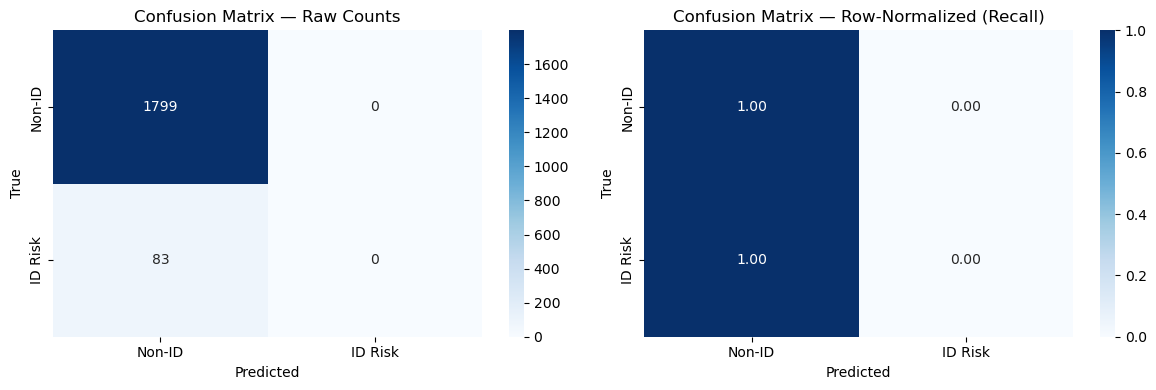

=== Ordinal DQ-Band Error (from regression head) ===
  Mean absolute band error : 2.888
  % exactly correct        : 2.4%
  % within 1 band          : 4.4%
  % off by 2+ bands        : 95.6%


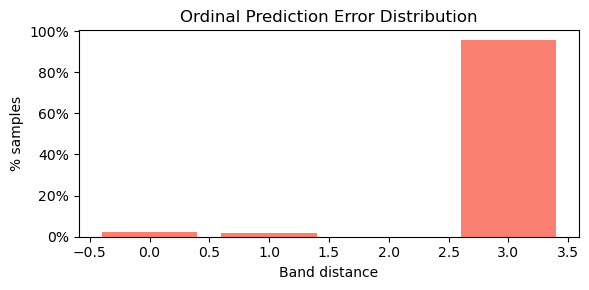

In [6]:
from sklearn.metrics import confusion_matrix

cm      = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title, fmt in zip(
        axes, [cm, cm_norm],
        ['Raw Counts', 'Row-Normalized (Recall)'],
        ['d', '.2f']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=['Non-ID', 'ID Risk'],
                yticklabels=['Non-ID', 'ID Risk'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {title}')
plt.tight_layout(); plt.show()

# ── Ordinal Band Error (using DQ-regression band mapping) ──────────────────
error_distances = np.abs(band_true - band_pred)
print('=== Ordinal DQ-Band Error (from regression head) ===')
print(f'  Mean absolute band error : {error_distances.mean():.3f}')
print(f'  % exactly correct        : {(error_distances == 0).mean()*100:.1f}%')
print(f'  % within 1 band          : {(error_distances <= 1).mean()*100:.1f}%')
print(f'  % off by 2+ bands        : {(error_distances >= 2).mean()*100:.1f}%')

vals, cnts = np.unique(error_distances, return_counts=True)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(vals, cnts / cnts.sum() * 100, color='salmon')
ax.set_xlabel('Band distance'); ax.set_ylabel('% samples')
ax.set_title('Ordinal Prediction Error Distribution')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()

## S7 — Per-Modality Ablation

  Full (EEG+MRI+HPO)        Macro F1 = 0.4887


  EEG only                  Macro F1 = 0.4887
  MRI only                  Macro F1 = 0.4887


  HPO only                  Macro F1 = 0.4887


  EEG + MRI                 Macro F1 = 0.4887


  EEG + HPO                 Macro F1 = 0.4887


  MRI + HPO                 Macro F1 = 0.4887


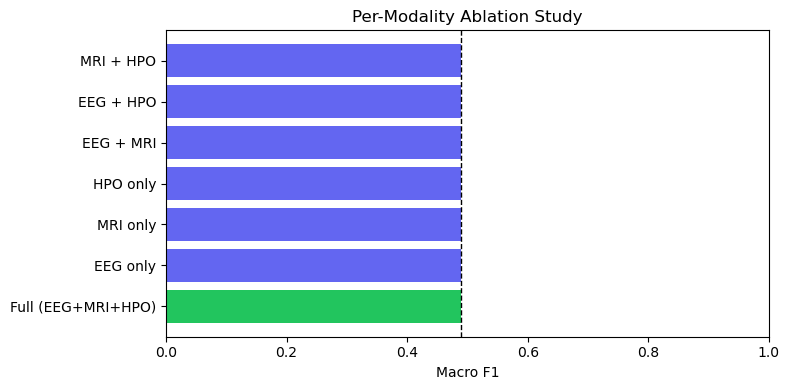

In [7]:
ABLATION_CONDITIONS = {
    'Full (EEG+MRI+HPO)': {'eeg': True, 'mri': True, 'hpo': True},
    'EEG only':           {'eeg': True, 'mri': False,'hpo': False},
    'MRI only':           {'eeg': False,'mri': True, 'hpo': False},
    'HPO only':           {'eeg': False,'mri': False,'hpo': True},
    'EEG + MRI':          {'eeg': True, 'mri': True, 'hpo': False},
    'EEG + HPO':          {'eeg': True, 'mri': False,'hpo': True},
    'MRI + HPO':          {'eeg': False,'mri': True, 'hpo': True},
}

ablation_results = {}

for cond_name, use in ABLATION_CONDITIONS.items():
    abl_preds = []
    with torch.no_grad():
        for batch in test_loader:
            model_in = {}
            if use['eeg'] and 'eeg' in batch:
                model_in['eeg'] = batch['eeg'].to(DEVICE)
            if use['mri'] and 'mri' in batch:
                mri = batch['mri']
                if mri.ndim == 4:
                    mri = mri.unsqueeze(2)
                model_in['mri'] = mri.to(DEVICE)
            if use['hpo'] and 'hpo' in batch:
                model_in['hpo'] = batch['hpo'].to(DEVICE)

            if not model_in:
                # No enabled modality present in this batch — skip
                abl_preds.extend([0] * batch['label'].shape[0])
                continue

            out = fusion_model(model_in)
            abl_preds.extend(out['logits'].argmax(-1).cpu().numpy().tolist())

    abl_f1 = f1_score(y_true, np.array(abl_preds), average='macro', zero_division=0)
    ablation_results[cond_name] = abl_f1
    print(f'  {cond_name:<25} Macro F1 = {abl_f1:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
names = list(ablation_results.keys())
scores = [ablation_results[n] for n in names]
colors = ['#22c55e' if 'Full' in n else '#6366f1' for n in names]
ax.barh(names, scores, color=colors)
ax.axvline(ablation_results['Full (EEG+MRI+HPO)'], color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Macro F1'); ax.set_title('Per-Modality Ablation Study')
ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()

## S8 — Calibration Analysis

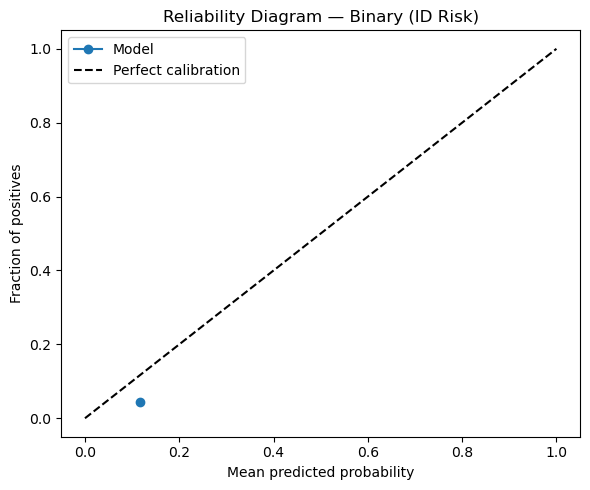

ECE (binary positive class): 0.0736
  ✅ ECE within acceptable range.


In [8]:
from sklearn.calibration import calibration_curve

# Binary calibration (positive class = ID risk)
fig, ax = plt.subplots(figsize=(6, 5))
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
ax.plot(prob_pred, prob_true, marker='o', label='Model')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Reliability Diagram — Binary (ID Risk)')
ax.legend(); plt.tight_layout(); plt.show()

# ── ECE (manual, no external dep) ───────────────────────────────────────────
def ece_score(y_true_bin, y_prob_pos, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    N = len(y_true_bin)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob_pos >= lo) & (y_prob_pos < hi)
        if mask.sum() == 0:
            continue
        acc  = y_true_bin[mask].mean()
        conf = y_prob_pos[mask].mean()
        ece += mask.sum() / N * abs(acc - conf)
    return ece

ece = ece_score(y_true, y_prob)
print(f'ECE (binary positive class): {ece:.4f}')
if ece > 0.10:
    print('  ⚠️  ECE > 0.10 — consider temperature scaling before deployment.')
else:
    print('  ✅ ECE within acceptable range.')

## S9 — DQ Severity Band Evaluation

=== Binary Screening Metrics (Non-ID vs ID-Risk) ===
  Sensitivity     0.0000
  Specificity     1.0000
  PPV             nan
  NPV             0.9559
  AUC-ROC         0.8986

=== DQ Regression (continuous head) ===
  MAE  = 41.57 DQ points
  RMSE = 42.40 DQ points


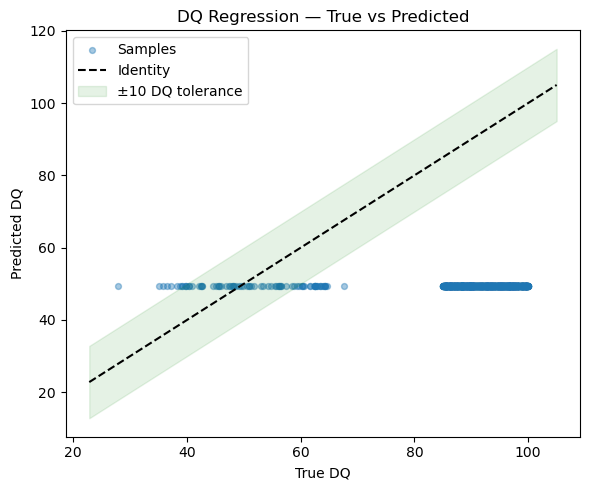

In [9]:
from sklearn.metrics import roc_auc_score as auc_score

# ── 9.1 Binary collapsed metrics ─────────────────────────────────────────────
def binary_stats(y_t, y_p, y_prob):
    tp = ((y_t == 1) & (y_p == 1)).sum()
    tn = ((y_t == 0) & (y_p == 0)).sum()
    fp = ((y_t == 0) & (y_p == 1)).sum()
    fn = ((y_t == 1) & (y_p == 0)).sum()
    sens = tp / (tp + fn) if (tp + fn) else float('nan')
    spec = tn / (tn + fp) if (tn + fp) else float('nan')
    ppv  = tp / (tp + fp) if (tp + fp) else float('nan')
    npv  = tn / (tn + fn) if (tn + fn) else float('nan')
    auc  = auc_score(y_t, y_prob) if len(np.unique(y_t)) > 1 else float('nan')
    return {'Sensitivity': sens, 'Specificity': spec,
            'PPV': ppv, 'NPV': npv, 'AUC-ROC': auc}

# Grouping A: binary label (already our y_true)
stats_a = binary_stats(y_true, y_pred, y_prob)
print('=== Binary Screening Metrics (Non-ID vs ID-Risk) ===')
for k, v in stats_a.items():
    print(f'  {k:<15} {v:.4f}')

# ── 9.2 DQ Regression Quality ─────────────────────────────────────────────
mae  = np.abs(dq_true - dq_pred).mean()
rmse = np.sqrt(((dq_true - dq_pred) ** 2).mean())
print(f'\n=== DQ Regression (continuous head) ===')
print(f'  MAE  = {mae:.2f} DQ points')
print(f'  RMSE = {rmse:.2f} DQ points')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(dq_true, dq_pred, alpha=0.4, s=18, label='Samples')
lo, hi = min(dq_true.min(), dq_pred.min()) - 5, max(dq_true.max(), dq_pred.max()) + 5
ax.plot([lo, hi], [lo, hi], 'k--', label='Identity')
ax.fill_between([lo, hi], [lo-10, hi-10], [lo+10, hi+10],
                alpha=0.1, color='green', label='±10 DQ tolerance')
ax.set_xlabel('True DQ'); ax.set_ylabel('Predicted DQ')
ax.set_title('DQ Regression — True vs Predicted')
ax.legend(); plt.tight_layout(); plt.show()

## S10 — ROC / PR Curves & Threshold Analysis

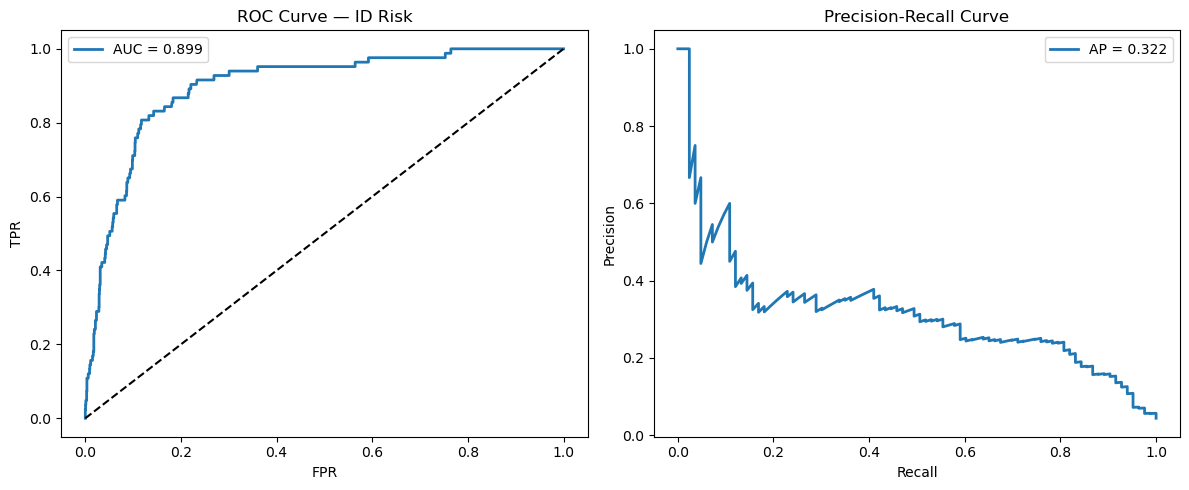

AUC-ROC = 0.8986  |  Average Precision = 0.3217


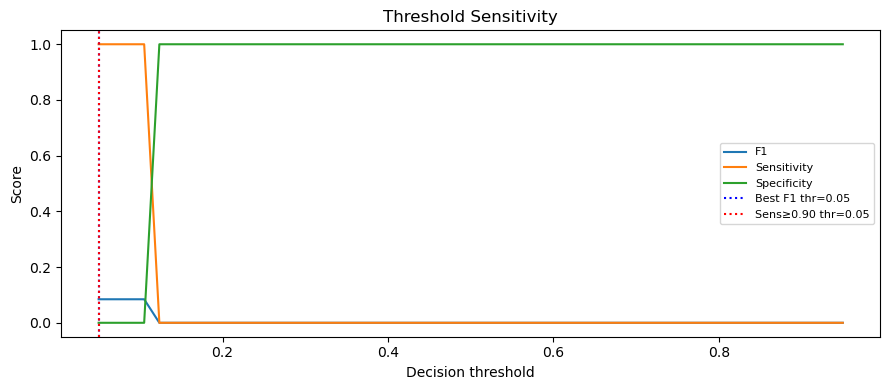

In [10]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ── ROC ──────────────────────────────────────────────────────────────────────
if len(np.unique(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_val:.3f}')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title('ROC Curve — ID Risk')
    ax.legend()

    # ── Precision-Recall ────────────────────────────────────────────────────
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    ax = axes[1]
    ax.plot(rec, prec, lw=2, label=f'AP = {ap:.3f}')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve')
    ax.legend()

    plt.tight_layout(); plt.show()
    print(f'AUC-ROC = {roc_auc_val:.4f}  |  Average Precision = {ap:.4f}')

    # ── Threshold sensitivity sweep ─────────────────────────────────────────
    thresholds = np.linspace(0.05, 0.95, 50)
    thr_df = []
    for thr in thresholds:
        yp = (y_prob >= thr).astype(int)
        thr_df.append({
            'threshold': thr,
            'F1':        f1_score(y_true, yp, zero_division=0),
            'Sens':      recall_score(y_true, yp, zero_division=0),
            'Spec':      recall_score(1 - y_true, 1 - yp, zero_division=0),
        })
    thr_df = pd.DataFrame(thr_df)

    best_f1_thr = thr_df.loc[thr_df['F1'].idxmax(), 'threshold']
    high_sens_thr = thr_df[thr_df['Sens'] >= 0.90]['threshold'].min() if (thr_df['Sens'] >= 0.90).any() else None

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(thr_df['threshold'], thr_df['F1'],   label='F1')
    ax.plot(thr_df['threshold'], thr_df['Sens'],  label='Sensitivity')
    ax.plot(thr_df['threshold'], thr_df['Spec'],  label='Specificity')
    ax.axvline(best_f1_thr, color='blue', linestyle=':', label=f'Best F1 thr={best_f1_thr:.2f}')
    if high_sens_thr:
        ax.axvline(high_sens_thr, color='red', linestyle=':', label=f'Sens≥0.90 thr={high_sens_thr:.2f}')
    ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score')
    ax.set_title('Threshold Sensitivity')
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()
else:
    print('⚠️  Only one class in test set — skipping ROC/PR.')

## S11 — Attention / Feature Visualization

In [11]:
# ── 11.1 MRI Grad-CAM ──────────────────────────────────────────────────────
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image

    # Target last block of features
    target_layer = mri_encoder.backbone[-1]

    # Grab one MRI sample from test set
    sample_mri = None
    for batch in test_loader:
        if 'mri' in batch:
            sample_mri = batch['mri'][0:1]  # (1,3,H,W)
            if sample_mri.ndim == 4:
                sample_mri = sample_mri.unsqueeze(2)  # (1,3,1,H,W)
            break

    if sample_mri is not None:
        # Wrapper for Grad-CAM compatibility (expects 2D spatial output)
        class MRISliceWrapper(torch.nn.Module):
            def __init__(self, encoder):
                super().__init__()
                self.enc = encoder
            def forward(self, x_2d):
                # x_2d: (B, 1, H, W)
                return self.enc.backbone(x_2d)

        wrapper = MRISliceWrapper(mri_encoder).to(DEVICE)
        cam = GradCAM(model=wrapper, target_layers=[list(wrapper.enc.backbone)[-1]])

        # Use axial slice (index 0)
        axial = sample_mri[0, 0]  # (1,H,W)
        inp = axial.unsqueeze(0).to(DEVICE)  # (1,1,H,W)
        grayscale_cam = cam(input_tensor=inp)[0]

        rgb_img = np.stack([axial.squeeze().numpy()] * 3, axis=-1)
        rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)
        vis = show_cam_on_image(rgb_img.astype(np.float32), grayscale_cam, use_rgb=True)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(axial.squeeze(), cmap='gray'); axes[0].set_title('MRI Axial Slice')
        axes[1].imshow(vis); axes[1].set_title('Grad-CAM Overlay')
        for ax in axes: ax.axis('off')
        plt.suptitle('MRI Grad-CAM'); plt.tight_layout(); plt.show()
    else:
        print('No MRI samples found in test set — skipping Grad-CAM.')
except ImportError:
    print('pytorch_grad_cam not installed. Run: pip install grad-cam')

pytorch_grad_cam not installed. Run: pip install grad-cam


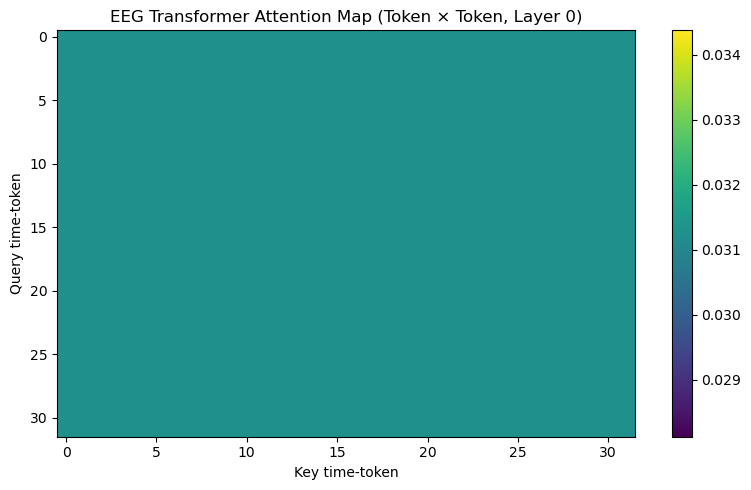

In [12]:
# ── 11.2 EEG Transformer Attention ─────────────────────────────────────────
attention_maps = []

def _attn_hook(module, input, output):
    # TransformerEncoderLayer returns the tensor, not (output, weights)
    # We capture via the parent MultiheadAttention
    pass

# A simpler approach: manually pass through and grab attention
sample_eeg = None
for batch in test_loader:
    if 'eeg' in batch:
        sample_eeg = batch['eeg'][0:1].to(DEVICE)  # (1, 19, 7680)
        break

if sample_eeg is not None:
    with torch.no_grad():
        f1 = eeg_encoder.branch_fast(sample_eeg)
        f2 = eeg_encoder.branch_theta(sample_eeg)
        f3 = eeg_encoder.branch_delta(sample_eeg)
        h = torch.cat([f1, f2, f3], dim=1)
        h = eeg_encoder.bn(h)
        h = eeg_encoder.pool(h)       # (1, 192, 32)
        h_seq = h.permute(0, 2, 1)    # (1, 32, 192)

        # Extract attention weights from transformer layer 0
        layer0 = eeg_encoder.transformer.layers[0]
        attn_out, attn_weights = layer0.self_attn(
            h_seq, h_seq, h_seq, need_weights=True, average_attn_weights=True
        )  # attn_weights: (1, 32, 32)

    attn_w = attn_weights[0].cpu().numpy()  # (32, 32)

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(attn_w, aspect='auto', cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_title('EEG Transformer Attention Map (Token × Token, Layer 0)')
    ax.set_xlabel('Key time-token'); ax.set_ylabel('Query time-token')
    plt.tight_layout(); plt.show()
else:
    print('No EEG samples found — skipping EEG attention plot.')

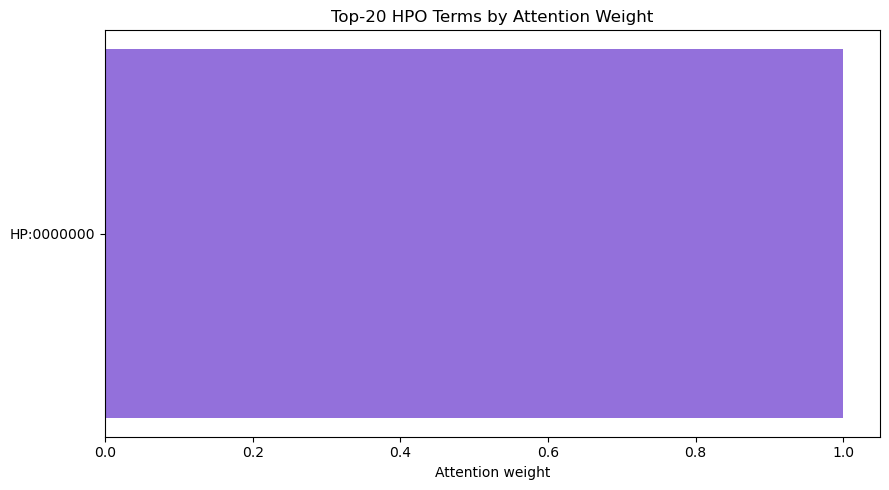

In [13]:
# ── 11.3 HPO Term Importance ─────────────────────────────────────────────
HPO_TERM_NAMES = {
    252:  'Microcephaly',      316: 'Hypertelorism',
    431:  'Wide nasal bridge', 322: 'Short philtrum',
    1263: 'Global dev. delay', 1249:'Intellectual disability',
    750:  'Speech delay',      1290:'Hypotonia',
    1256: 'Mild ID',           2342:'Moderate ID',
}

sample_hpo = None
for batch in test_loader:
    if 'hpo' in batch:
        sample_hpo = batch['hpo'][0:1].to(DEVICE)
        break

if sample_hpo is not None:
    with torch.no_grad():
        if hpo_encoder.input_pad is not None:
            x = hpo_encoder.input_pad(sample_hpo)
        else:
            x = sample_hpo
        x = hpo_encoder.input_norm(x)
        x_seq = x.unsqueeze(1)
        _, attn_w = hpo_encoder.self_attn(x_seq, x_seq, x_seq,
                                           need_weights=True, average_attn_weights=True)

    attn_vec = attn_w[0, 0, :cfg.model.hpo_n_features].cpu().numpy()
    top_k = 20
    top_idx = np.argsort(attn_vec)[::-1][:top_k]
    top_scores = attn_vec[top_idx]
    top_labels = [HPO_TERM_NAMES.get(i, f'HP:{i:07d}') for i in top_idx]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(top_labels[::-1], top_scores[::-1], color='mediumpurple')
    ax.set_xlabel('Attention weight')
    ax.set_title(f'Top-{top_k} HPO Terms by Attention Weight')
    plt.tight_layout(); plt.show()
else:
    print('No HPO samples found — skipping HPO importance plot.')

## S12 — Latency & Memory Profiling

  BS= 1  mean=375.1ms  p95=451.9ms  per-sample=375.1ms


  BS= 4  mean=524.9ms  p95=608.3ms  per-sample=131.2ms


  BS= 8  mean=1552.2ms  p95=2234.7ms  per-sample=194.0ms


  BS=16  mean=2954.5ms  p95=3804.6ms  per-sample=184.7ms


  BS=32  mean=5151.4ms  p95=7005.6ms  per-sample=161.0ms


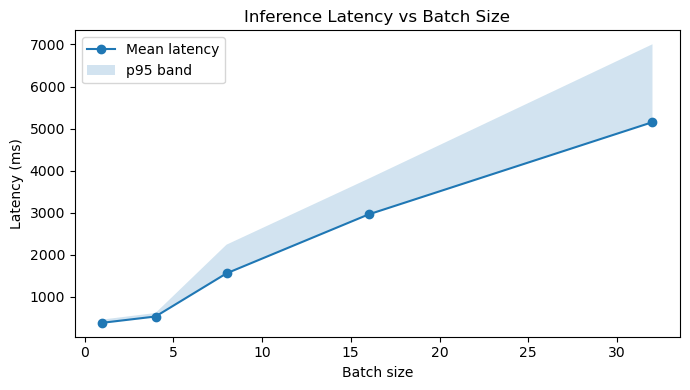

CPU-only mode — skipping GPU memory profiling.


In [14]:
latency_results = {}

for bs in [1, 4, 8, 16, 32]:
    dummy = {
        'eeg': torch.randn(bs, 19, 7680, device=DEVICE),
        'mri': torch.randn(bs, 3, 1, 64, 64, device=DEVICE),
        'hpo': torch.randn(bs, cfg.model.hpo_n_features, device=DEVICE),
    }
    # Warm-up
    for _ in range(5):
        with torch.no_grad():
            _ = fusion_model(dummy)

    times = []
    for _ in range(30):
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = fusion_model(dummy)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)

    times = np.array(times)
    latency_results[bs] = {
        'mean_ms':       round(float(times.mean()), 2),
        'p50_ms':        round(float(np.percentile(times, 50)), 2),
        'p95_ms':        round(float(np.percentile(times, 95)), 2),
        'per_sample_ms': round(float(times.mean()) / bs, 2),
    }
    print(f'  BS={bs:2d}  mean={times.mean():.1f}ms  p95={np.percentile(times,95):.1f}ms  per-sample={times.mean()/bs:.1f}ms')

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
bs_vals  = list(latency_results.keys())
mean_lat = [latency_results[b]['mean_ms'] for b in bs_vals]
p95_lat  = [latency_results[b]['p95_ms']  for b in bs_vals]
ax.plot(bs_vals, mean_lat, marker='o', label='Mean latency')
ax.fill_between(bs_vals, mean_lat, p95_lat, alpha=0.2, label='p95 band')
ax.set_xlabel('Batch size'); ax.set_ylabel('Latency (ms)')
ax.set_title('Inference Latency vs Batch Size'); ax.legend()
plt.tight_layout(); plt.show()

# Memory
if DEVICE.type == 'cuda':
    torch.cuda.reset_peak_memory_stats()
    dummy_bs1 = {
        'eeg': torch.randn(1, 19, 7680, device=DEVICE),
        'mri': torch.randn(1, 3, 1, 64, 64, device=DEVICE),
        'hpo': torch.randn(1, cfg.model.hpo_n_features, device=DEVICE),
    }
    with torch.no_grad():
        _ = fusion_model(dummy_bs1)
    peak_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    print(f'Peak GPU Memory (BS=1): {peak_mb:.1f} MB')
else:
    print('CPU-only mode — skipping GPU memory profiling.')

## S13 — Export Evaluation Report

In [15]:
import subprocess

eval_report = {
    'generated_at':     datetime.now().isoformat(),
    'checkpoint_dir':   str(CKPT_DIR),
    'test_samples':     int(len(y_true)),
    'device':           str(DEVICE),
    'overall_metrics':  {k: float(v) for k, v in metrics.items()},
    'binary_screening': {k: float(v) for k, v in stats_a.items()},
    'dq_regression':    {'mae': float(mae), 'rmse': float(rmse)},
    'ordinal_error': {
        'mean_band_error': float(error_distances.mean()),
        'pct_exact':       float((error_distances == 0).mean()),
        'pct_within_1':    float((error_distances <= 1).mean()),
        'pct_off_2plus':   float((error_distances >= 2).mean()),
    },
    'ablation_macro_f1': {k: float(v) for k, v in ablation_results.items()},
    'calibration_ece':   float(ece),
    'latency_ms':        latency_results,
}

report_path = PROJECT_ROOT / 'reports' / 'eval_report.json'
with open(report_path, 'w') as f:
    json.dump(eval_report, f, indent=2)
print(f'Saved JSON report: {report_path}')

# Export notebook as clean HTML
result = subprocess.run(
    ['jupyter', 'nbconvert', '--to', 'html', '--no-input',
     str(PROJECT_ROOT / 'evaluation.ipynb'),
     '--output', str(PROJECT_ROOT / 'reports' / 'evaluation_report.html')],
    capture_output=True, text=True
)
if result.returncode == 0:
    print('Saved HTML report: reports/evaluation_report.html')
else:
    print(f'nbconvert error: {result.stderr}')

print('\n=== Final Summary ===')
for k, v in eval_report['overall_metrics'].items():
    print(f'  {k:<28} {v:.4f}')

Saved JSON report: /Users/rickyk/Coding/Deeo Learning/Id predictor/reports/eval_report.json


Saved HTML report: reports/evaluation_report.html

=== Final Summary ===
  Accuracy                     0.9559
  Balanced Accuracy            0.5000
  Macro F1                     0.4887
  Weighted F1                  0.9343
  Macro Precision              0.4779
  Macro Recall                 0.5000
  Matthews Corr Coef           0.0000
  Cohen Kappa                  0.0000
  ROC AUC                      0.8986
